# Comparing all conditions - with generation feedback and without it - Does our generation feedback improve descriptions?
### description lengths - "token_num"
### validated objects - all objects + hallucinations by each subject - per attempt and per condition
###  gen images similarity - are gen images when aiming for that look more similar to the original image than ones based on descriptions that were not meant for it (without our feedback)
### exploratory analyses - how many erasings, how many additions of words per attempt...



In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [2]:
import sys
from pathlib import Path
# Make sure we can import config.py from project root

# One folder up from current notebook location
project_root = Path.cwd().parent.parent.resolve()

# Add subdirectories to path
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'config'))
print(f"Project root: {project_root}")
import config
import yaml

Project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [50]:
# df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/feedback_vs_no_feedback.csv")
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/all_feedback_no_feedback.csv")
save_path = "/mnt/hdd/anatkorol/Imagination_in_translation/analysis/comparing_conditions"
#with feedback:
perception_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
memory_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
delay_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09032026_pilot_2_delayed_memory_digit-span/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
# no feedback:

perception_no_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/29032026_pilot_2_perception_no_feedback/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
memory_no_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/07052026_pilot_2_immediate_memory_no_feedback/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
delay_no_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/07052026_pilot_2_delayed_memory_digit_span_no_feedback/nlp_analysis/ppt_trials_w_object_validation.csv").copy()

#new condition - analysis on it's own
no_attempts = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/240526_pilot_2_immediate_memory_no_feedback_no_attempts/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
#deleting gpt-5 rows from all dfs
perception_feedback = perception_feedback[perception_feedback['uid'] != "gpt-5"]
memory_feedback = memory_feedback[memory_feedback['uid'] != "gpt-5"]
delay_feedback = delay_feedback[delay_feedback['uid'] != "gpt-5"]

In [51]:
# #adding condition and feedback columns
# perception_feedback["condition"] = "perception"
# perception_feedback["feedback"] = "feedback"

# memory_feedback["condition"] = "immediate memory"
# memory_feedback["feedback"] = "feedback"

# delay_feedback["condition"] = "delayed memory"
# delay_feedback["feedback"] = "feedback"

# perception_no_feedback["condition"] = "perception"
# perception_no_feedback["feedback"] = "no-feedback"

# memory_no_feedback["condition"] = "immediate memory"
# memory_no_feedback["feedback"] = "no-feedback"

# delay_no_feedback["condition"] = "delayed memory"
# delay_no_feedback["feedback"] = "no-feedback"


# df = pd.concat([perception_feedback, memory_feedback, delay_feedback, perception_no_feedback, memory_no_feedback, delay_no_feedback], ignore_index=True)
# #df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/all_feedback_no_feedback.csv", index=False)

In [52]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'item_evaluations',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects', 'error', 'condition',
       'feedback', 'clip_cosine_distance', 'vgg_fc7_distance',
       'clip_vis_text_similarity', 'token_num_x', 'token_num_y', 'token_num'],
      dtype='object')

In [53]:
# turning the category details into actual lists instead of strings
import ast
list_cols = ['objects', 'attr_color', 'spatial_relations', 'subjective_detail'] 

# turning the python strings into real lists
def to_list(x):
    # Already a list
    if isinstance(x, list):
        return x
    # Missing values
    if pd.isna(x):
        return []
    # String that looks like a list
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "null":
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else []
            except Exception:
                return []
    # Anything else
    return []

def converted (df):
    # Convert columns to real lists
    for c in list_cols:
        if c in df.columns:
            df[c] = df[c].apply(to_list)
    return df


#apply conversion to each df
df = converted(df)
no_attempts = converted(no_attempts)


# comparing by prompt length

In [54]:
df['prompt_word_count'] = df['prompt'].fillna('').str.split().str.len()
df['prompt_char_count'] = df['prompt'].fillna('').str.len()
no_attempts['prompt_word_count'] = no_attempts['prompt'].fillna('').str.split().str.len()
no_attempts['prompt_char_count'] = no_attempts['prompt'].fillna('').str.len()

In [55]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'item_evaluations',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects', 'error', 'condition',
       'feedback', 'clip_cosine_distance', 'vgg_fc7_distance',
       'clip_vis_text_similarity', 'token_num_x', 'token_num_y', 'token_num',
       'prompt_word_count', 'prompt_char_count'],
      dtype='object')

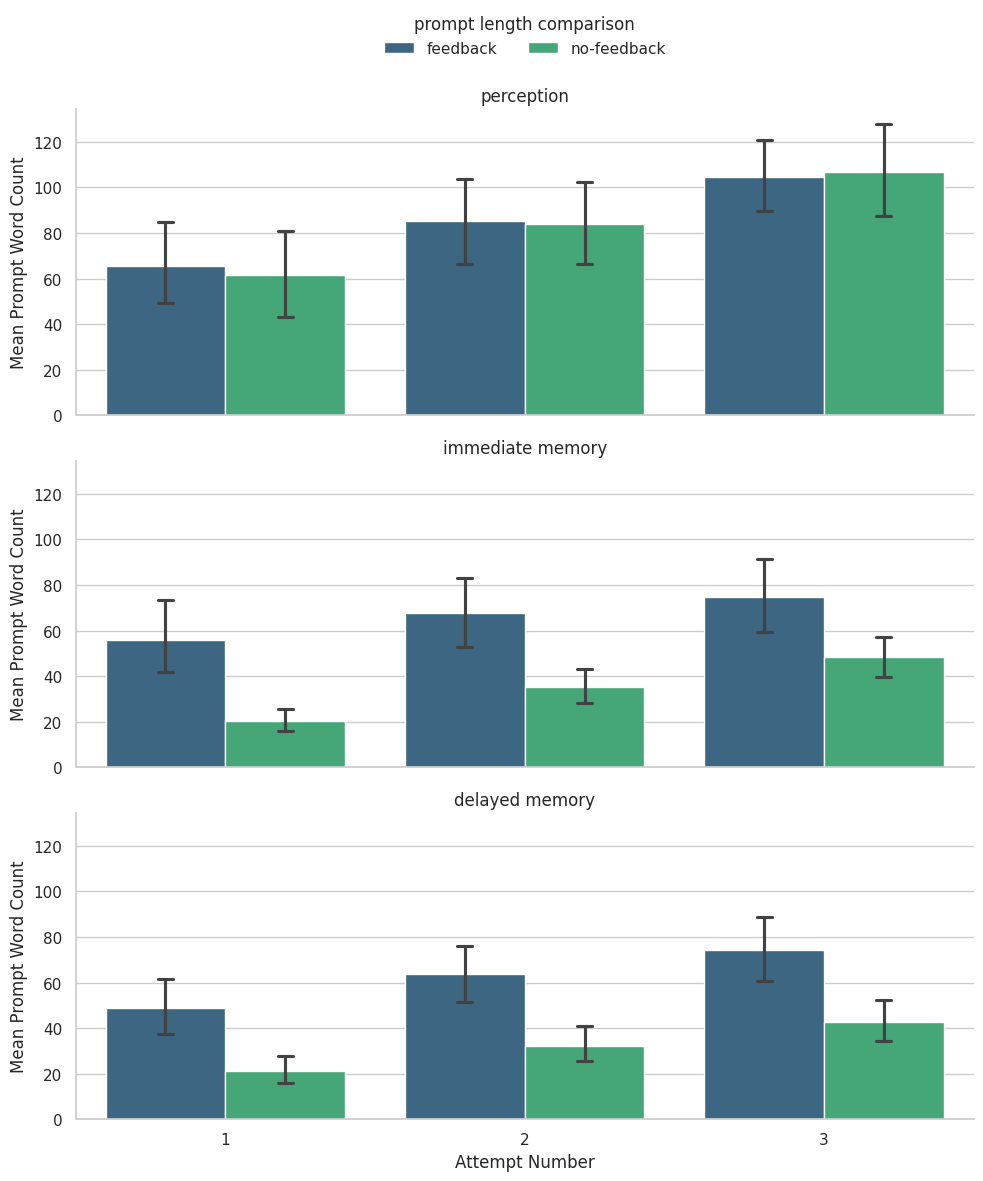

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the grid
g = sns.FacetGrid(
    df, 
    row="condition", 
    row_order=['perception', 'immediate memory', 'delayed memory'],
    height=4, 
    aspect=2.5, 
    sharex=True
)

# Map the barplot (ensure legend=False so we can customize its position)
g.map_dataframe(
    sns.barplot, 
    x="attempt", 
    y="prompt_word_count", 
    hue="feedback", 
    palette="viridis",
    capsize=.1
)

# Remove the automatic legend and titles to clear space
g.set_titles(row_template="{row_name}")
g.set_axis_labels("Attempt Number", "Mean Prompt Word Count")

# Place the legend at the top
# bbox_to_anchor coordinates: (x, y, width, height)
plt.legend(
    title="prompt length comparison", 
    bbox_to_anchor=(0.5, 3.65), # Adjust the 3.65 based on final plot scaling
    loc='upper center', 
    ncol=2, 
    frameon=False
)

# Adjust subplots to make room for the legend at the top
plt.subplots_adjust(top=0.9)
plt.show()

# comparison by number of validated objects

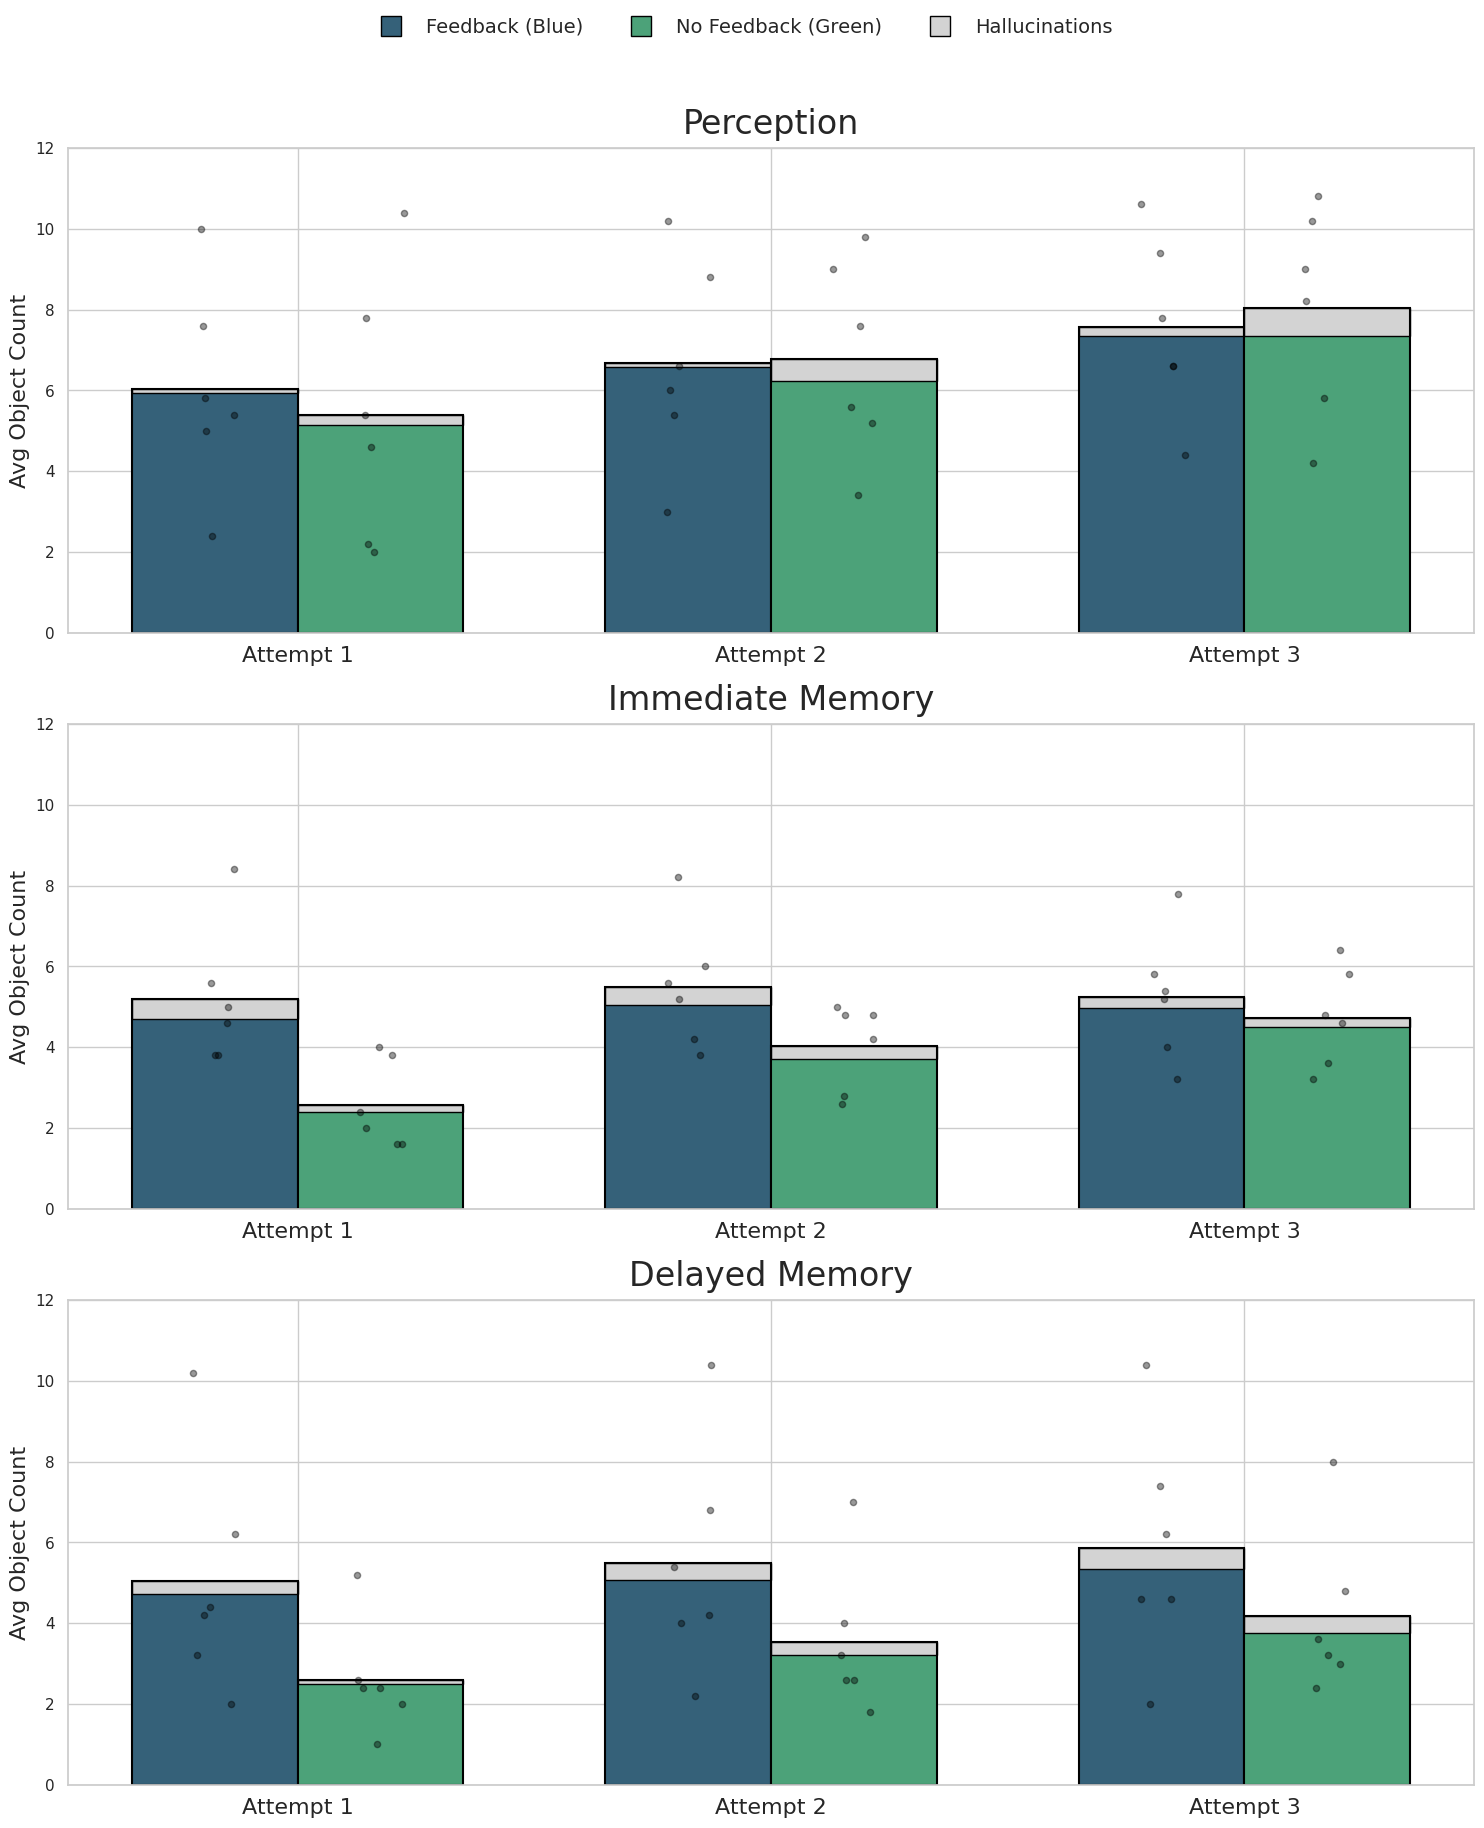

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Aggregation Logic
# First, aggregate by user to get the average performance per subject
per_user_stats = df.groupby(['uid', 'condition', 'feedback', 'attempt']).agg({
    'n_validated': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()

# Calculate total extracted for the individual jitter dots
per_user_stats['total_extracted'] = per_user_stats['n_validated'] + per_user_stats['n_invalid_not_in_image']

# 2. Setup the Plotting Environment
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

condition_order = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]
feedbacks = ['feedback', 'no-feedback']

# Define Colors: Blue for Feedback, Green for No-Feedback
colors = {'feedback': '#356179', 'no-feedback': '#4ca279'} 
grey_color = '#d3d3d3'

width = 0.35 
x_base = np.arange(len(attempts))

# 3. Iterative Plotting per Condition
for idx, cond in enumerate(condition_order):
    ax = axes[idx]
    cond_data = per_user_stats[per_user_stats['condition'] == cond]
    
    for i, att in enumerate(attempts):
        for j, fb in enumerate(feedbacks):
            # Calculate x-position for grouped bars
            # Feedback is on the left (-0.5 offset), No-Feedback on the right (+0.5 offset)
            pos = i + (j - 0.5) * width 
            
            subset = cond_data[(cond_data['attempt'] == att) & (cond_data['feedback'] == fb)]
            
            if not subset.empty:
                mean_val = subset['n_validated'].mean()
                mean_halluc = subset['n_invalid_not_in_image'].mean()
                total = mean_val + mean_halluc
                
                # Layer 1: Validated Objects (Blue/Green)
                ax.bar(pos, mean_val, width, color=colors[fb], edgecolor='none')
                
                # Layer 2: Hallucinations (Grey Stacked on Top)
                ax.bar(pos, mean_halluc, width, bottom=mean_val, 
                       color=grey_color, edgecolor='black', linewidth=1)
                
                # Layer 3: Full Outer Border
                ax.bar(pos, total, width, fill=False, edgecolor='black', linewidth=1.5)
                
                # Layer 4: Participant Jitter Dots
                x_jitter = np.random.uniform(-0.05, 0.05, len(subset))
                ax.scatter(np.full(len(subset), pos) + x_jitter, subset['total_extracted'], 
                           color='black', alpha=0.4, s=20, zorder=3)

    # Subplot Formatting
    ax.set_title(cond.title(), fontsize=24, pad=10)
    ax.set_ylabel('Avg Object Count', fontsize=16)
    ax.set_xticks(x_base)
    ax.set_xticklabels([f"Attempt {a}" for a in attempts], fontsize=16)
    
    # Optional: Set a consistent Y-limit across all rows for better visual comparison
    ax.set_ylim(0, 12) 

# 4. Global Legend at the Top
legend_elements = [
    Line2D([0], [0], color=colors['feedback'], lw=0, label='Feedback (Blue)', 
           marker='s', markeredgecolor='black', markersize=15),
    Line2D([0], [0], color=colors['no-feedback'], lw=0, label='No Feedback (Green)', 
           marker='s', markeredgecolor='black', markersize=15),
    Line2D([0], [0], color=grey_color, lw=0, label='Hallucinations', 
           marker='s', markeredgecolor='black', markersize=15)
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
           ncol=3, fontsize=14, frameon=False)

# Final adjustments to layout
plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

# computing pbjective similarity scores between conditions:

In [ ]:
similarity_df = pd.read_csv(Path(project_root / "Data" / "processed_data" / "comparing_conditions" / "all_feedback_no_feedback_with_similarity.csv")).copy()

In [30]:

# # 1. Define your project root relative to this notebook

# # 2. Load the YAML mapping file
# YAML_PATH = project_root / "condition_maps.yaml"
# with open(YAML_PATH, "r") as f:
#     mapping_data = yaml.safe_load(f)

# conditions_dict = mapping_data["CONDITIONS"]

# # 3. Loop through all conditions, filter out gpt-5, and store them
# all_dfs = []

# for cond_name, info in conditions_dict.items():
#     csv_path = project_root / "Data" / "processed_data" / info["processed_sub"] / info["df"]
    
#     try:
#         # Load the CSV
#         temp_df = pd.read_csv(csv_path).copy()
        
#         # --- NEW FILTER RULE ---
#         # Keep only rows where 'uid' is NOT equal to 'gpt-5'
#         # (Using standard string comparison or handling potential missing 'uid' columns safely)
#         if "uid" in temp_df.columns:
#             initial_count = len(temp_df)
#             temp_df = temp_df[temp_df["uid"] != "gpt-5"]
#             excluded_count = initial_count - len(temp_df)
#             print(f"Loading {cond_name}: Excluded {excluded_count} row(s) matching uid == 'gpt-5'")
#         else:
#             print(f"Loading {cond_name}: ⚠️ 'uid' column not found, skipping filter step.")
#         # ------------------------
        
#         # --- MAP THE NEW CLEAN LABELS ---
#         # Instead of parsing strings, directly assign the values from the YAML mapping
#         temp_df["condition"] = info["task"]      # "perception", "immediate memory", "delayed memory"
#         temp_df["feedback"] = info["feedback"]    # "feedback", "no feedback"
        
#         # Keep this just in case you ever need to debug the raw folder source
#         temp_df["condition_full_name"] = cond_name
        
#         all_dfs.append(temp_df)
        
#     except FileNotFoundError:
#         print(f"⚠️ Warning: File not found for '{cond_name}'. Skipping.")

# # 4. Concatenate everything into one master DataFrame
# if all_dfs:
#     similarity_df = pd.concat(all_dfs, ignore_index=True)
#     print(f"\nSuccessfully combined {len(all_dfs)} conditions!")
#     print(f"Final Master DataFrame Shape: {master_df.shape}")
# else:
#     print("\n❌ No dataframes were loaded.")

In [31]:
# similarity_df.to_csv(project_root / "Data" / "processed_data" / "comparing_conditions" / "all_feedback_no_feedback_with_similarity.csv", index=False)

In [39]:
similarity_df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity',
       'clip_cosine_distance', 'vgg_fc7_distance', 'clip_vis_text_similarity',
       'token_num', 'condition', 'feedback', 'condition_full_name',
       'revised_prompt'],
      dtype='object')

In [51]:
similarity_df["vgg_similarity"] = 1 - similarity_df["vgg_fc7_distance"]
similarity_df["clip_similarity"] = 1 - similarity_df["clip_cosine_distance"]


In [ ]:
# turning cosine distance into similarity!!!


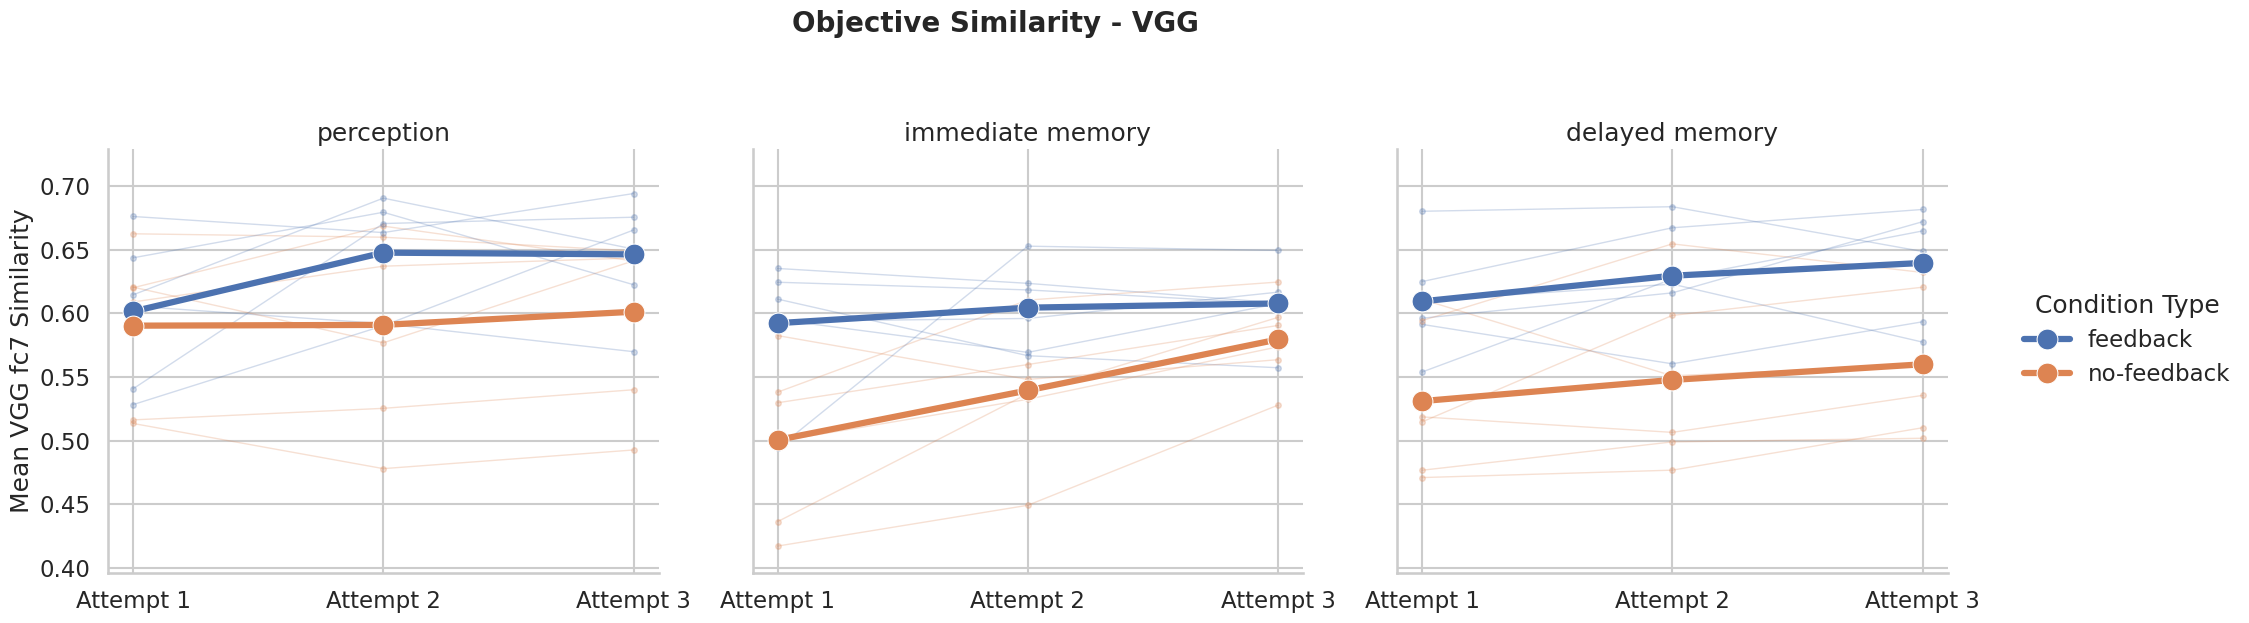

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = similarity_df.copy()

# =====================================================================
# CONFIGURABLE METRIC SWITCH
# =====================================================================
# Change this string to switch metrics (e.g., "clip_similarity", "vgg_similarity")
SIMILARITY_METRIC = "vgg_similarity"  
# =====================================================================

# 1. Clean data: Ensure attempts are integers
df_plot = df_plot[df_plot["attempt"].isin([1, 2, 3])]
df_plot["attempt"] = df_plot["attempt"].astype(int)

# Standardize values to eliminate any space vs hyphen inconsistencies
df_plot["feedback"] = df_plot["feedback"].str.replace(" ", "-")

# Dynamic generation of similarity columns if they are still distances
if SIMILARITY_METRIC == "vgg_similarity" and "vgg_similarity" not in df_plot.columns:
    df_plot['vgg_similarity'] = 1 - df_plot['vgg_fc7_distance']
elif SIMILARITY_METRIC == "clip_similarity" and "clip_similarity" not in df_plot.columns:
    df_plot['clip_similarity'] = 1 - df_plot['clip_cosine_distance']

# 2. Aggregate data by participant (uid)
df_uid = (
    df_plot
    .groupby(["uid", "condition", "feedback", "attempt"], as_index=False)[SIMILARITY_METRIC]
    .mean()
)

# Set up the plotting style
sns.set_theme(style="whitegrid", context="talk")

# 3. Create a FacetGrid
g = sns.FacetGrid(
    df_uid, 
    col="condition", 
    col_order=["perception", "immediate memory", "delayed memory"],
    height=6, 
    aspect=1.0
)

# 4. Robust custom mapping function
def draw_participant_trends(data, **kwargs):
    if data.empty:
        return
    
    # Map explicit hex keys matching the main summary lines
    colors = {"feedback": "#4c72b0", "no-feedback": "#dd8452"}
    
    # Group by BOTH participant and their feedback assignment block
    for (uid_name, feedback_type), sub in data.groupby(["uid", "feedback"]):
        sub = sub.sort_values("attempt")
        color = colors.get(str(feedback_type), "gray")
        
        plt.plot(
            sub["attempt"], 
            sub[SIMILARITY_METRIC],
            marker="o", 
            markersize=4,      
            alpha=0.25,        
            linewidth=1, 
            color=color, 
            zorder=1
        )

# Step A: Draw individual participant trajectories across both feedback dimensions
g.map_dataframe(draw_participant_trends, hue="feedback")

# Step B: Superimpose the heavy population summary trends on top
g.map_dataframe(
    sns.lineplot, 
    x="attempt", 
    y=SIMILARITY_METRIC,
    hue="feedback", 
    hue_order=["feedback", "no-feedback"],
    palette={"feedback": "#4c72b0", "no-feedback": "#dd8452"}, 
    marker="o", 
    markersize=15, 
    linewidth=4.5,
    errorbar=None, 
    zorder=5
)

# 5. Clean axes labels, limits, and typography
metric_title_map = {
    "vgg_similarity": "VGG fc7 Similarity",
    "clip_similarity": "CLIP Visual Similarity"
}
y_label = metric_title_map.get(SIMILARITY_METRIC, SIMILARITY_METRIC.replace("_", " ").title())

g.set_titles(template="{col_name}")
g.set_axis_labels("", f"Mean {y_label}")

for ax in g.axes.flat:
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Attempt 1", "Attempt 2", "Attempt 3"])
    
    # Pad y-axis limits gracefully around real distribution minimums/maximums
    y_min = df_uid[SIMILARITY_METRIC].min()
    y_max = df_uid[SIMILARITY_METRIC].max()
    ax.set_ylim(y_min * 0.95, min(1.0, y_max * 1.05))

# Position master legend and global header text blocks cleanly
g.add_legend(title="Condition Type", loc="center right", bbox_to_anchor=(1.12, 0.5))

title_prefix = "Objective Similarity" if "similarity" in SIMILARITY_METRIC else "Objective Distance"
plt.suptitle(f"{title_prefix} - {SIMILARITY_METRIC.split('_')[0].upper()}", y=1.05, fontsize=20, weight="bold")

plt.tight_layout()
plt.show()

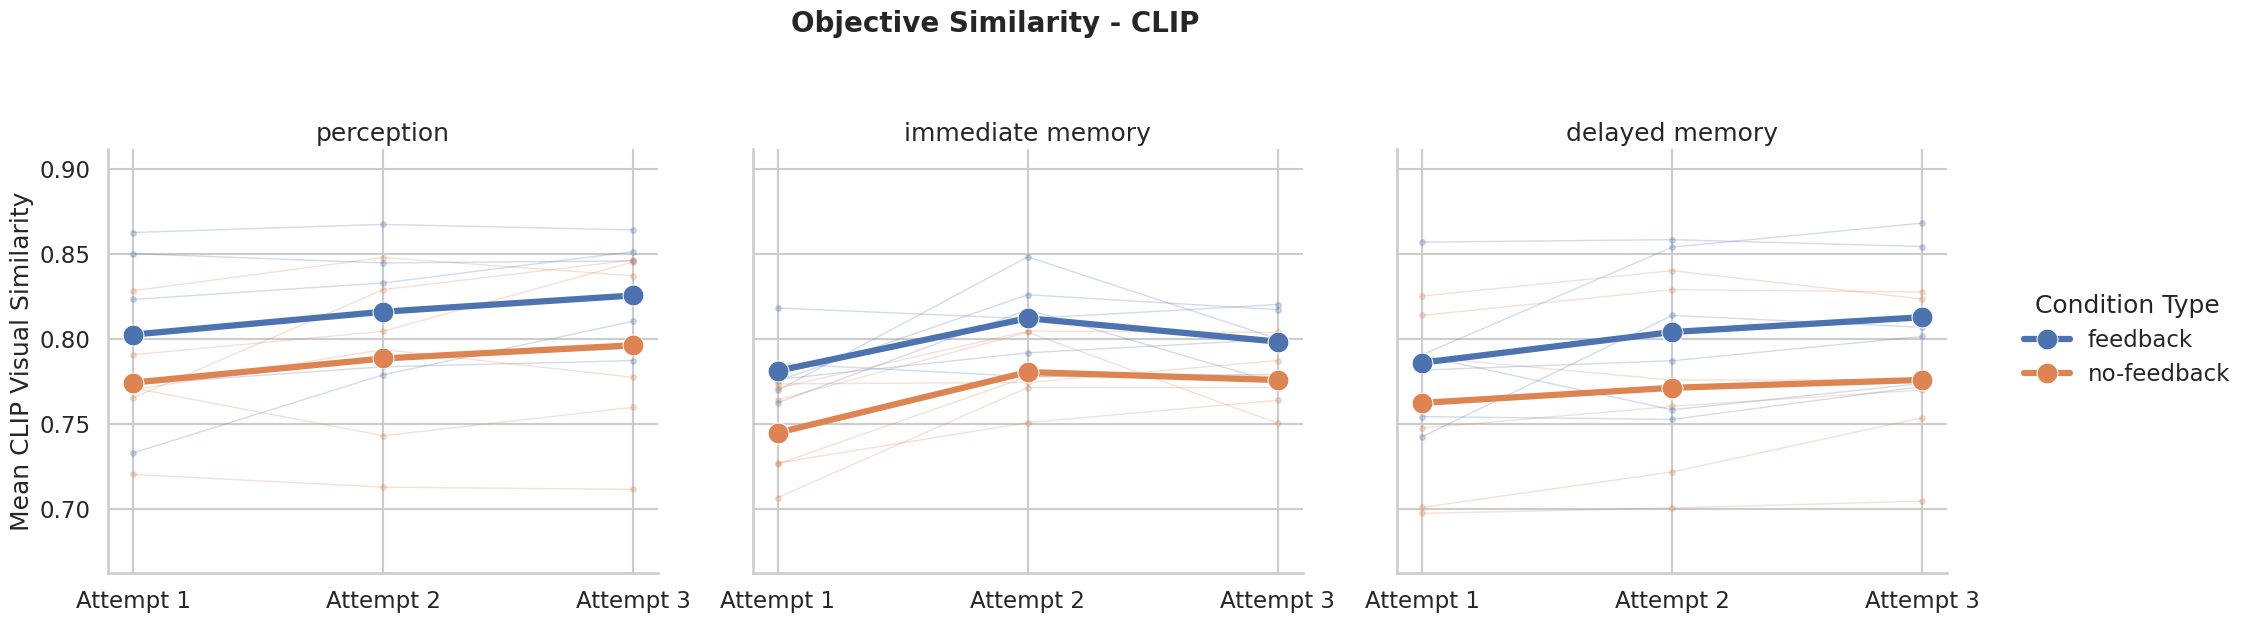

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = similarity_df.copy()

# =====================================================================
# CONFIGURABLE METRIC SWITCH
# =====================================================================
# Change this string to switch metrics (e.g., "clip_similarity", "vgg_similarity")
SIMILARITY_METRIC = "clip_similarity"  
# =====================================================================

# 1. Clean data: Ensure attempts are integers
df_plot = df_plot[df_plot["attempt"].isin([1, 2, 3])]
df_plot["attempt"] = df_plot["attempt"].astype(int)

# Standardize values to eliminate any space vs hyphen inconsistencies
df_plot["feedback"] = df_plot["feedback"].str.replace(" ", "-")

# Dynamic generation of similarity columns if they are still distances
if SIMILARITY_METRIC == "vgg_similarity" and "vgg_similarity" not in df_plot.columns:
    df_plot['vgg_similarity'] = 1 - df_plot['vgg_fc7_distance']
elif SIMILARITY_METRIC == "clip_similarity" and "clip_similarity" not in df_plot.columns:
    df_plot['clip_similarity'] = 1 - df_plot['clip_cosine_distance']

# 2. Aggregate data by participant (uid)
df_uid = (
    df_plot
    .groupby(["uid", "condition", "feedback", "attempt"], as_index=False)[SIMILARITY_METRIC]
    .mean()
)

# Set up the plotting style
sns.set_theme(style="whitegrid", context="talk")

# 3. Create a FacetGrid
g = sns.FacetGrid(
    df_uid, 
    col="condition", 
    col_order=["perception", "immediate memory", "delayed memory"],
    height=6, 
    aspect=1.0
)

# 4. Robust custom mapping function
def draw_participant_trends(data, **kwargs):
    if data.empty:
        return
    
    # Map explicit hex keys matching the main summary lines
    colors = {"feedback": "#4c72b0", "no-feedback": "#dd8452"}
    
    # Group by BOTH participant and their feedback assignment block
    for (uid_name, feedback_type), sub in data.groupby(["uid", "feedback"]):
        sub = sub.sort_values("attempt")
        color = colors.get(str(feedback_type), "gray")
        
        plt.plot(
            sub["attempt"], 
            sub[SIMILARITY_METRIC],
            marker="o", 
            markersize=4,      
            alpha=0.25,        
            linewidth=1, 
            color=color, 
            zorder=1
        )

# Step A: Draw individual participant trajectories across both feedback dimensions
g.map_dataframe(draw_participant_trends, hue="feedback")

# Step B: Superimpose the heavy population summary trends on top
g.map_dataframe(
    sns.lineplot, 
    x="attempt", 
    y=SIMILARITY_METRIC,
    hue="feedback", 
    hue_order=["feedback", "no-feedback"],
    palette={"feedback": "#4c72b0", "no-feedback": "#dd8452"}, 
    marker="o", 
    markersize=15, 
    linewidth=4.5,
    errorbar=None, 
    zorder=5
)

# 5. Clean axes labels, limits, and typography
metric_title_map = {
    "vgg_similarity": "VGG fc7 Similarity",
    "clip_similarity": "CLIP Visual Similarity"
}
y_label = metric_title_map.get(SIMILARITY_METRIC, SIMILARITY_METRIC.replace("_", " ").title())

g.set_titles(template="{col_name}")
g.set_axis_labels("", f"Mean {y_label}")

for ax in g.axes.flat:
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Attempt 1", "Attempt 2", "Attempt 3"])
    
    # Pad y-axis limits gracefully around real distribution minimums/maximums
    y_min = df_uid[SIMILARITY_METRIC].min()
    y_max = df_uid[SIMILARITY_METRIC].max()
    ax.set_ylim(y_min * 0.95, min(1.0, y_max * 1.05))

# Position master legend and global header text blocks cleanly
g.add_legend(title="Condition Type", loc="center right", bbox_to_anchor=(1.12, 0.5))

title_prefix = "Objective Similarity" if "similarity" in SIMILARITY_METRIC else "Objective Distance"
plt.suptitle(f"{title_prefix} - {SIMILARITY_METRIC.split('_')[0].upper()}", y=1.05, fontsize=20, weight="bold")

plt.tight_layout()
plt.show()

# plots by same feedback type

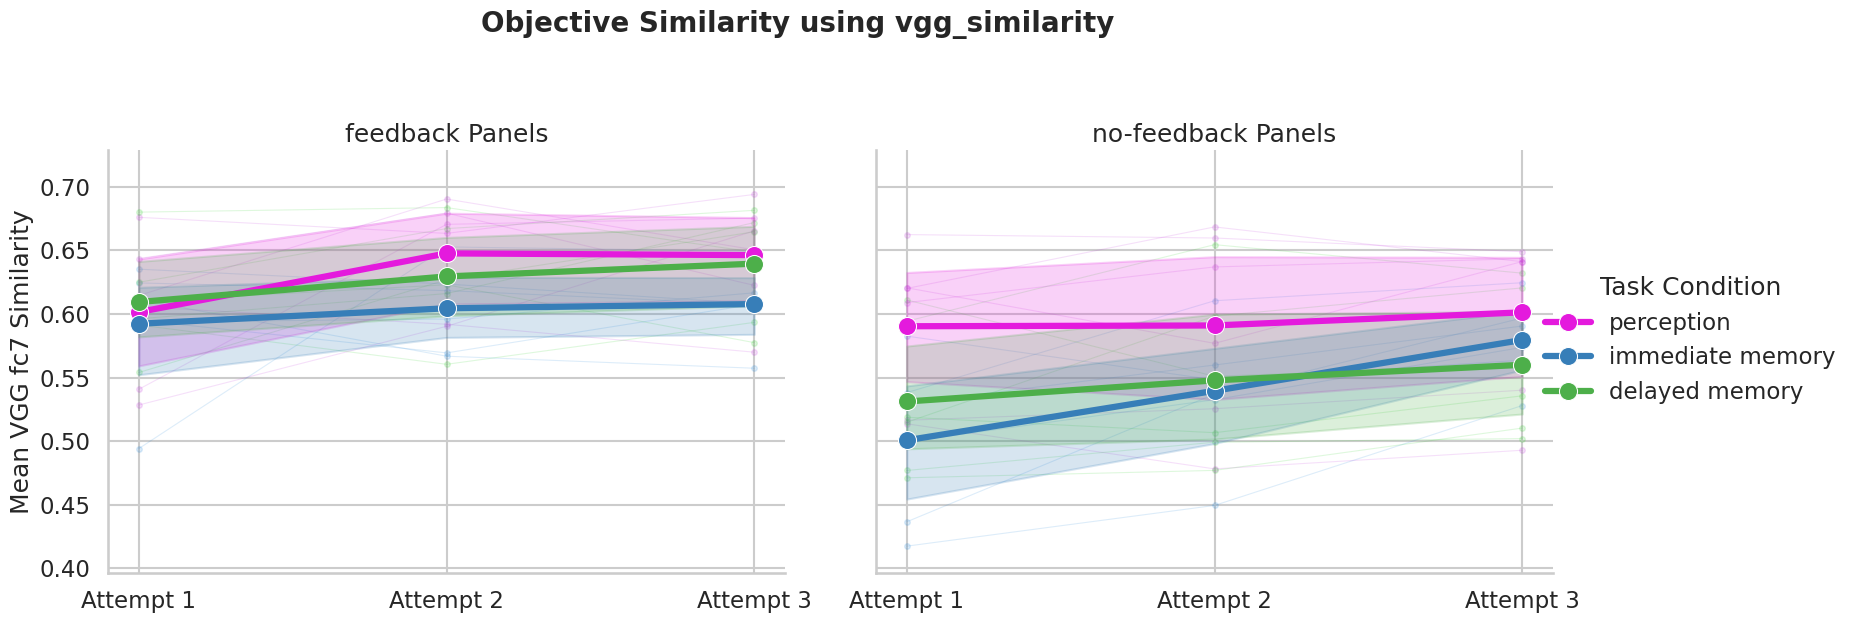

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = similarity_df.copy()

# =====================================================================
# CONFIGURABLE METRIC SWITCH
# =====================================================================
# Change this string to switch metrics (e.g., "clip_similarity", "vgg_similarity")
SIMILARITY_METRIC = "vgg_similarity"  
# =====================================================================

# 1. Clean data: Ensure attempts are integers
df_plot = df_plot[df_plot["attempt"].isin([1, 2, 3])]
df_plot["attempt"] = df_plot["attempt"].astype(int)

# Standardize values to eliminate any space vs hyphen inconsistencies
df_plot["feedback"] = df_plot["feedback"].str.replace(" ", "-")

# Dynamic generation of similarity columns if they are still stored as raw distances
if SIMILARITY_METRIC == "vgg_similarity" and "vgg_similarity" not in df_plot.columns:
    df_plot['vgg_similarity'] = 1 - df_plot['vgg_fc7_distance']
elif SIMILARITY_METRIC == "clip_similarity" and "clip_similarity" not in df_plot.columns:
    df_plot['clip_similarity'] = 1 - df_plot['clip_cosine_distance']

# Aggregate data by participant (uid) to get clean mean trajectories per person
df_uid = (
    df_plot
    .groupby(["uid", "condition", "feedback", "attempt"], as_index=False)[SIMILARITY_METRIC]
    .mean()
)

# Set up the plotting style
sns.set_theme(style="whitegrid", context="talk")

# 2. Create the FacetGrid: 2 Columns split by Feedback Type
g = sns.FacetGrid(
    df_uid, 
    col="feedback", 
    col_order=["feedback", "no-feedback"],
    height=6, 
    aspect=1.1
)

# 3. Custom mapping function to overlay the background participant lines
def draw_inverted_participant_trends(data, **kwargs):
    if data.empty:
        return
    
    # Map explicit colors for the tasks to keep background lines matching the summary lines
    task_colors = {
        "perception": "#C030DD",       # Red
        "immediate memory": "#1d85db",  # Blue
        "delayed memory": "#27d121"     # Green
    }
    
    # Group by both participant and their specific task condition
    for (uid_name, task_type), sub in data.groupby(["uid", "condition"]):
        sub = sub.sort_values("attempt")
        color = task_colors.get(str(task_type), "gray")
        
        plt.plot(
            sub["attempt"], 
            sub[SIMILARITY_METRIC],
            marker="o", 
            markersize=4,      
            alpha=0.15,        # Light opacity to keep the density cloud clean
            linewidth=0.8, 
            color=color, 
            zorder=1
        )

# Step A: Draw individual trajectories for all participants across both subplots
g.map_dataframe(draw_inverted_participant_trends)

# Step B: Superimpose the heavy population summary lines on top with error bars
g.map_dataframe(
    sns.lineplot, 
    x="attempt", 
    y=SIMILARITY_METRIC,
    hue="condition", 
    hue_order=["perception", "immediate memory", "delayed memory"],
    palette={"perception": "#e41add", "immediate memory": "#377eb8", "delayed memory": "#4daf4a"}, 
    marker="o", 
    markersize=13, 
    linewidth=4.5,
    errorbar="ci",      # Draws 95% confidence intervals across participant means
    #  capsize=0.05,
    zorder=5
)

# 4. Polish layouts, titles, axes labels, and formatting
metric_title_map = {
    "vgg_similarity": "VGG fc7 Similarity",
    "clip_similarity": "CLIP Visual Similarity"
}
y_label = metric_title_map.get(SIMILARITY_METRIC, SIMILARITY_METRIC.replace("_", " ").title())

# Clean up panel headers
g.set_titles(template="{col_name} Panels").set_xlabels("")
g.set_axis_labels("", f"Mean {y_label}")

for ax in g.axes.flat:
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Attempt 1", "Attempt 2", "Attempt 3"])
    
    # Standardize scale bounding based on your real values
    y_min = df_uid[SIMILARITY_METRIC].min()
    y_max = df_uid[SIMILARITY_METRIC].max()
    ax.set_ylim(y_min * 0.95, min(1.0, y_max * 1.05))

# Position master legend and global header elements cleanly without overlap
g.add_legend(title="Task Condition", loc="center right", bbox_to_anchor=(1.15, 0.5))

title_prefix = f"Objective Similarity using {SIMILARITY_METRIC}" 
plt.suptitle(f"{title_prefix}", y=1.05, fontsize=20, weight="bold")

plt.tight_layout()
plt.show()

#

# only for the no feedback no attempts imeciate memory condiiton

/tmp/ipykernel_21231/1342230770.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_21231/1342230770.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


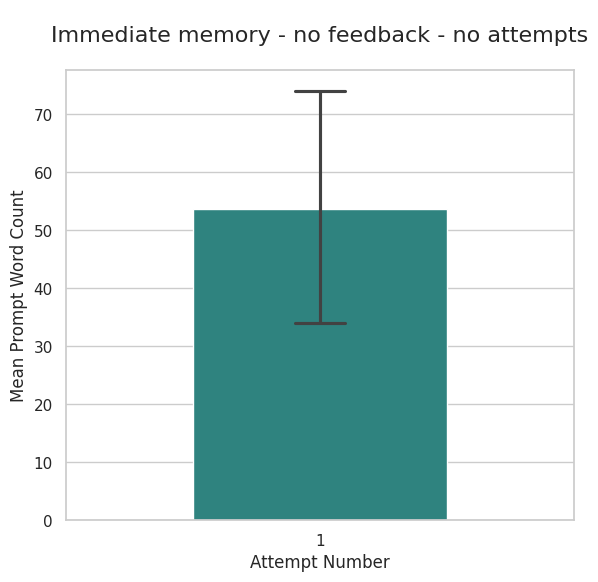

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
#also make bar thinner by setting width parameter in barplot to something like 0.5 or 0.3

# 2. Initialize a standard single subplot figure
fig, ax = plt.subplots(figsize=(6, 6))

# 3. Draw the barplot directly on the axis (ax)
sns.barplot(
    data=no_attempts, 
    x="attempt", 
    y="prompt_word_count", 
    palette="viridis",
    width=0.5,  # Make bars thinner
    capsize=.1,
    ax=ax
)

# 4. Set labels and title directly
ax.set_title("Immediate memory - no feedback - no attempts", fontsize=16, pad=20) # Optional title for the condition
ax.set_xlabel("Attempt Number", fontsize=12)
ax.set_ylabel("Mean Prompt Word Count", fontsize=12)

# 5. Clean up the legend and place it at the top center
# Because it's a single plot, bbox_to_anchor=(0.5, 1.15) works perfectly
ax.legend(
    bbox_to_anchor=(0.5, 1.15), 
    loc='upper center', 
    ncol=1, 
    frameon=False
)

# Adjust layout so the top legend doesn't get cut off
plt.tight_layout()
plt.show()

In [59]:
print(f'average word count for attempt 1: {no_attempts["prompt_word_count"].mean()}')

average word count for attempt 1: 53.63333333333333


In [60]:
print(f"average word count per uid for no attempts condition:")
print(no_attempts.groupby("uid")["prompt_word_count"].mean())

average word count per uid for no attempts condition:
uid
5tj71yiw1779539095737     63.4
7acjzuv61779478453694    171.8
abc6yf6h1779538522516     24.4
sqmy7pso1779539736765     16.4
t4sid6bt1779534662220      9.6
uegb9y7e1779536327590     36.2
Name: prompt_word_count, dtype: float64


In [61]:
#lets compare with regular
print("avergage word count for attempt 1 in condition immediate memory no feedback inside df:")
#select only relevant condition, then provide all results per participant:
immediate_memory_no_feedback_original_attempt_one = df[(df['condition'] == 'immediate memory') & (df['feedback'] == 'no-feedback') & (df['attempt'] == 1)]
print(immediate_memory_no_feedback_original_attempt_one.groupby("uid")["prompt_word_count"].mean())

avergage word count for attempt 1 in condition immediate memory no feedback inside df:
uid
jw22trv11778076299983    18.4
n3t9l1ee1778084250606    34.4
or90lghi1778066698471    10.6
rk1bbyar1778086560803     8.8
yhcjm7sd1778085548998    28.2
z8nlzig51778072881649    21.8
Name: prompt_word_count, dtype: float64


In [62]:
#lets compare with regular
print("avergage word count for attempt 1 in condition immediate memory with feedback inside df:")
#select only relevant condition, then provide all results per participant:
immediate_memory_no_feedback_original_attempt_one = df[(df['condition'] == 'immediate memory') & (df['feedback'] == 'feedback') & (df['attempt'] == 1)]
print(immediate_memory_no_feedback_original_attempt_one.groupby("uid")["prompt_word_count"].mean())

avergage word count for attempt 1 in condition immediate memory with feedback inside df:
uid
6wvnde9x1767643758827     28.6
7soec8jg1767640158456     53.2
df1argpl1767648299885    130.6
oiv8zavj1767639943374     30.0
qn36ndly1767638614323     44.4
tyrfv5eq1767635157270     48.4
Name: prompt_word_count, dtype: float64


# no attempts - comparing by number of validated objects

In [63]:
no_attempts.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'token_num', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'item_evaluations',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects', 'error',
       'prompt_word_count', 'prompt_char_count'],
      dtype='object')

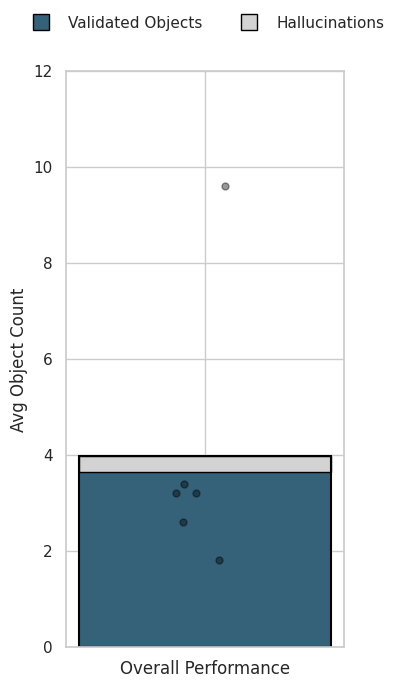

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Aggregation Logic (Simplified for a single global state)
per_user_stats = no_attempts.groupby(['uid']).agg({
    'n_validated': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()

# Calculate total extracted for the individual jitter dots
per_user_stats['total_extracted'] = per_user_stats['n_validated'] + per_user_stats['n_invalid_not_in_image']

# Calculate global means for our single stacked bar
mean_val = per_user_stats['n_validated'].mean()
mean_halluc = per_user_stats['n_invalid_not_in_image'].mean()
total = mean_val + mean_halluc

# 2. Setup a Compact Plotting Environment
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(4, 7)) # Narrower figure size for a single bar

# Styling choices
bar_color = '#356179' # Your consistent Blue
grey_color = '#d3d3d3'
bar_width = 0.4       # Keeps the single bar slim and centered
pos = 0               # Single x-axis position

# 3. Draw the Layers for the Single Stacked Bar
# Layer 1: Validated Objects (Blue Base)
ax.bar(pos, mean_val, bar_width, color=bar_color, edgecolor='none')

# Layer 2: Hallucinations (Grey Stacked on Top)
ax.bar(pos, mean_halluc, bar_width, bottom=mean_val, 
       color=grey_color, edgecolor='black', linewidth=1)

# Layer 3: Full Outer Border
ax.bar(pos, total, bar_width, fill=False, edgecolor='black', linewidth=1.5)

# Layer 4: Participant Jitter Dots
x_jitter = np.random.uniform(-0.05, 0.05, len(per_user_stats))
ax.scatter(np.full(len(per_user_stats), pos) + x_jitter, per_user_stats['total_extracted'], 
           color='black', alpha=0.4, s=25, zorder=3)

# 4. Formatting labels and cleanup

ax.set_ylabel('Avg Object Count', fontsize=12)

# Fix X-axis so it labels the single bar nicely instead of showing numeric coordinates
ax.set_xticks([pos])
ax.set_xticklabels(["Overall Performance"], fontsize=12)

# Set a safe y-limit based on data spread
ax.set_ylim(0, max(per_user_stats['total_extracted'].max() + 2, 12)) 

# 5. Legend at the Top
legend_elements = [
    Line2D([0], [0], color=bar_color, lw=0, label='Validated Objects', 
           marker='s', markeredgecolor='black', markersize=12),
    Line2D([0], [0], color=grey_color, lw=0, label='Hallucinations', 
           marker='s', markeredgecolor='black', markersize=12)
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.12), 
          ncol=2, fontsize=11, frameon=False)

plt.tight_layout()
plt.show()

In [68]:
print(f"average validated objects: {mean_val}")

average validated objects: 3.633333333333333


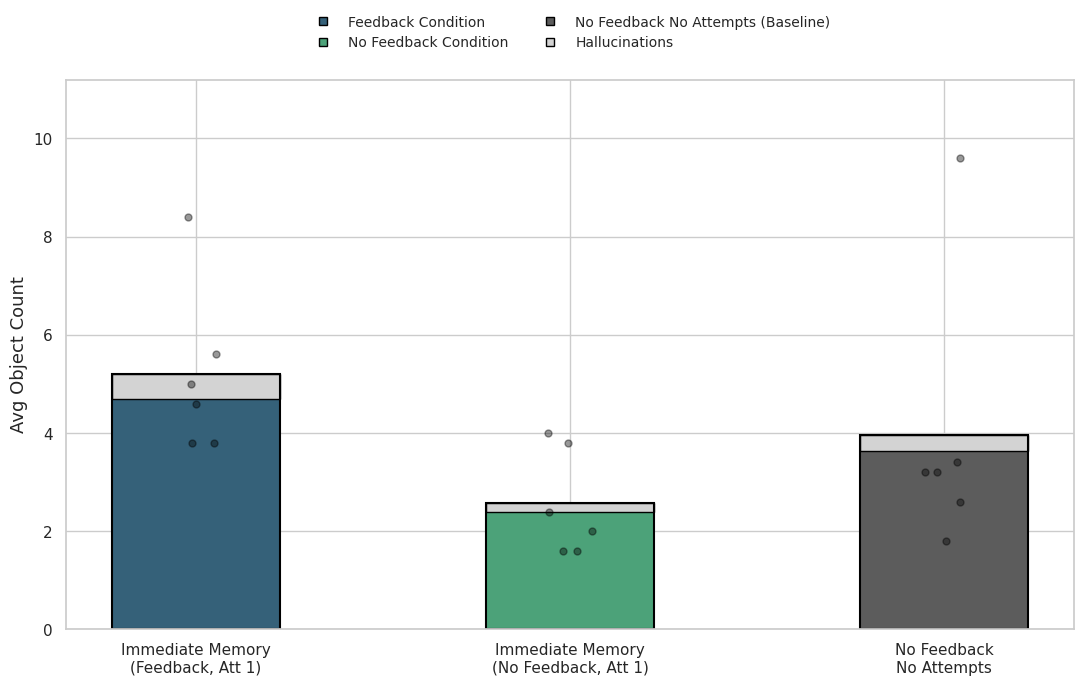

In [71]:
# comparing all three conditinons of feedback inside the immediate memory condition so that I can compare them:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Standardize and Extract the 3 Target Groups
# Group A: Immediate Memory + Feedback + Attempt 1
g_feedback = df[
    (df['condition'] == 'immediate memory') & 
    (df['feedback'] == 'feedback') & 
    (df['attempt'] == 1)
].groupby('uid').agg({'n_validated': 'mean', 'n_invalid_not_in_image': 'mean'}).reset_index()
g_feedback['group'] = 'Immediate Memory\n(Feedback, Att 1)'

# Group B: Immediate Memory + No Feedback + Attempt 1
g_no_feedback = df[
    (df['condition'] == 'immediate memory') & 
    (df['feedback'] == 'no-feedback') & 
    (df['attempt'] == 1)
].groupby('uid').agg({'n_validated': 'mean', 'n_invalid_not_in_image': 'mean'}).reset_index()
g_no_feedback['group'] = 'Immediate Memory\n(No Feedback, Att 1)'

# Group C: Baseline (No Feedback, No Attempts)
g_baseline = no_attempts.groupby('uid').agg({
    'n_validated': 'mean', 
    'n_invalid_not_in_image': 'mean'
}).reset_index()
g_baseline['group'] = 'No Feedback\nNo Attempts'

# 2. Combine the Aggregated Data for Easy Plotting Loops
groups_list = [g_feedback, g_no_feedback, g_baseline]
group_names = [g['group'].iloc[0] for g in groups_list]

# 3. Setup the Plotting Canvas
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 7))

# Color Assignments
# Blue for Feedback, Green for No Feedback, Dark Grey for the pure Control baseline
group_colors = {
    group_names[0]: '#356179', 
    group_names[1]: '#4ca279', 
    group_names[2]: '#5c5c5c'  
}
grey_hallucination = '#d3d3d3'
bar_width = 0.45

# 4. Draw the Stacked Bars and Individual Jitter Dots
for idx, g_data in enumerate(groups_list):
    name = group_names[idx]
    
    # Calculate means
    mean_val = g_data['n_validated'].mean()
    mean_halluc = g_data['n_invalid_not_in_image'].mean()
    total = mean_val + mean_halluc
    
    # Stacked Bars
    ax.bar(idx, mean_val, bar_width, color=group_colors[name], edgecolor='none')
    ax.bar(idx, mean_halluc, bar_width, bottom=mean_val, color=grey_hallucination, edgecolor='black', linewidth=1)
    ax.bar(idx, total, bar_width, fill=False, edgecolor='black', linewidth=1.5)
    
    # Raw Participant Variability (Dots)
    g_data['total_extracted'] = g_data['n_validated'] + g_data['n_invalid_not_in_image']
    x_jitter = np.random.uniform(-0.06, 0.06, len(g_data))
    ax.scatter(np.full(len(g_data), idx) + x_jitter, g_data['total_extracted'], 
               color='black', alpha=0.4, s=25, zorder=3)

# 5. Final Formatting Polish
#put title higher so that it doesn't interfere with the legend
# ax.set_title("Baseline Intervention Comparison (Immediate Memory)", fontsize=16, pad=25, fontweight='bold')
ax.set_ylabel("Avg Object Count", fontsize=13)
ax.set_xticks(range(len(group_names)))
ax.set_xticklabels(group_names, fontsize=11)

# Dynamically safe Y-limit
max_dot_value = max([g['n_validated'].mean() + g['n_invalid_not_in_image'].mean() for g in groups_list])
ax.set_ylim(0, max_dot_value + 6)

# 6. Global Legend Setup
legend_elements = [
    Line2D([0], [0], color=group_colors[group_names[0]], lw=0, label='Feedback Condition', marker='s', markeredgecolor='black'),
    Line2D([0], [0], color=group_colors[group_names[1]], lw=0, label='No Feedback Condition', marker='s', markeredgecolor='black'),
    Line2D([0], [0], color=group_colors[group_names[2]], lw=0, label='No Feedback No Attempts (Baseline)', marker='s', markeredgecolor='black'),
    Line2D([0], [0], color=grey_hallucination, lw=0, label='Hallucinations', marker='s', markeredgecolor='black')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=2, fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

## comparing them based on token_num (length of description)

OLD - # let's compare counts - objects, spatial relations and color attributes

In [33]:
selected_columns = ["objects", "spatial_relations", "attr_color", "attr_size", "attr_texture", "camera_aspects"]

In [39]:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long = df.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long["count"] = long["items"].apply(safe_len)

# Keep category order as selected_columns
long["category"] = pd.Categorical(long["category"], categories=selected_columns, ordered=True)

In [46]:
#great aggregation but no variance per participant
# # Assuming your dataframe is named 'df'
# # Aggregating across participants (uid) and images (gt) - they are averaged out in the process, so we get a single mean count per category/condition/attempt
condition_order = ['feedback', 'no_feedback']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()

# Sort for consistent plotting (Attempt 1, 2, 3)
agg_df = agg_df.sort_values(by=['category', 'condition', 'attempt'])


/tmp/ipykernel_294642/4021671284.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()


In [47]:
agg_df

,category,condition,attempt,count
0,objects,feedback,1,7.600000
1,objects,feedback,2,8.433333
2,objects,feedback,3,9.033333
3,objects,no_feedback,1,6.466667
4,objects,no_feedback,2,8.166667
5,objects,no_feedback,3,9.733333
6,spatial_relations,feedback,1,3.400000
7,spatial_relations,feedback,2,4.300000
8,spatial_relations,feedback,3,5.333333
9,spatial_relations,no_feedback,1,2.633333


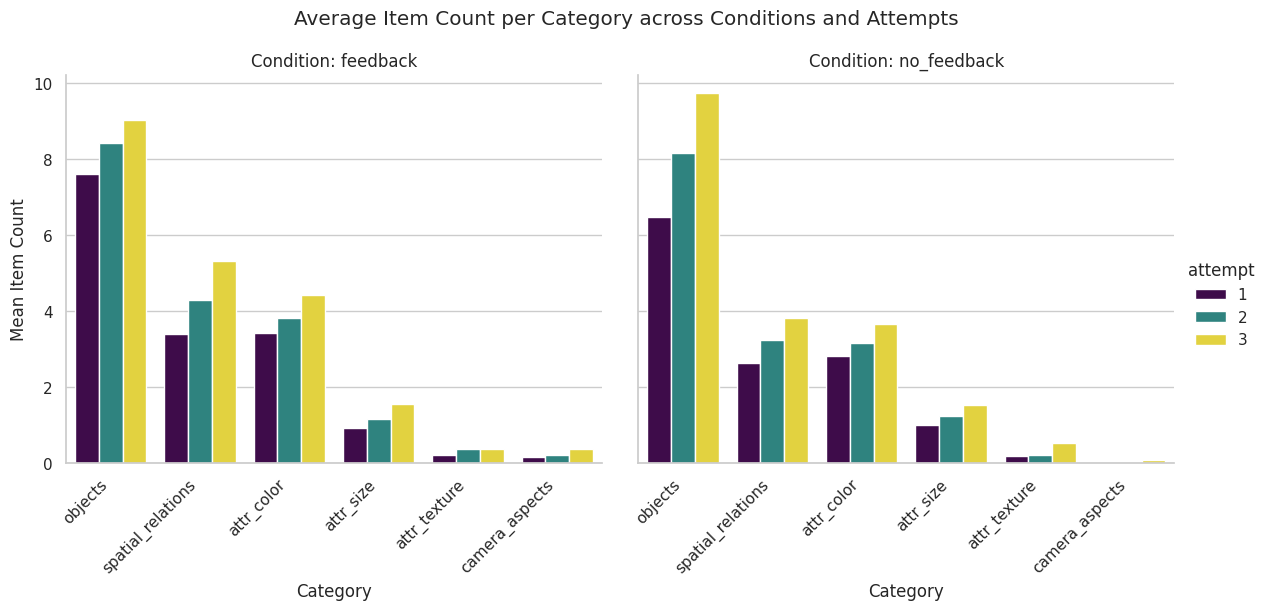

In [48]:
# Setting up the visual style
sns.set_theme(style="whitegrid")

# Creating the faceted bar plot
g = sns.catplot(
    data=agg_df, 
    x='category', 
    y='count', 
    hue='attempt', 
    col='condition', 
    kind='bar',
    palette='viridis',
    height=5, 
    aspect=1.2
)
# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Customizing labels and titles
g.set_axis_labels("Category", "Mean Item Count")
g.set_titles("Condition: {col_name}")
g.fig.suptitle('Average Item Count per Category across Conditions and Attempts', y=1.05)

# plt.savefig('category_analysis_plot.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_294642/3530377025.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_294642/3530377025.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


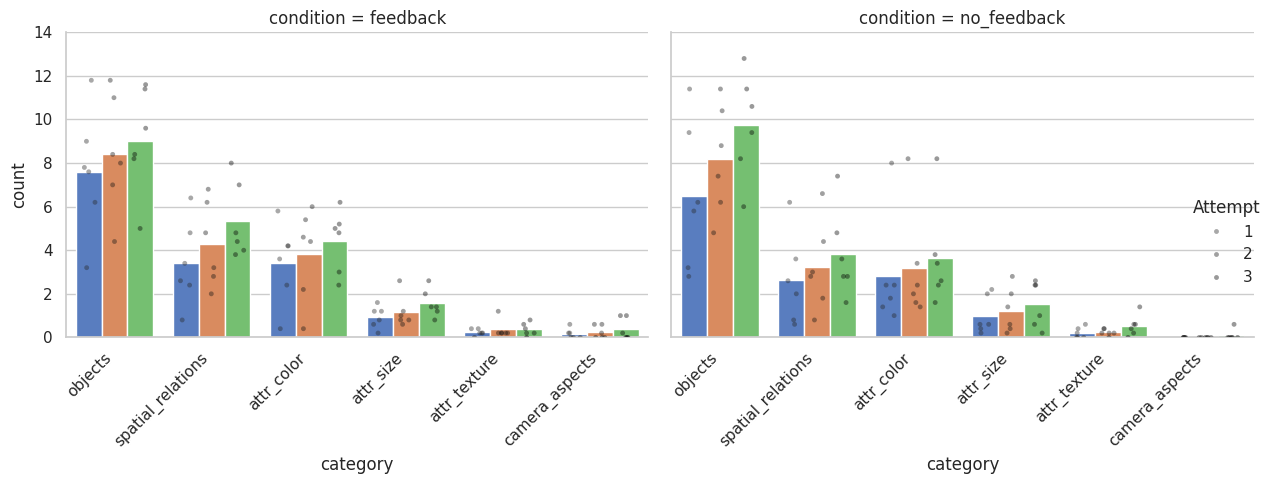

In [54]:
# looking at the individual participants

# Correct Aggregation
# We include 'condition' in the groupby to keep the participant tied to their group.
# We average the 'count' (averaging across the multiple images 'gt' each person saw).
df_participant = long.groupby(
    ['condition', 'uid', 'category', 'attempt'], 
    as_index=False, 
    observed=True  # IMPORTANT: This prevents pandas from creating empty rows for 
                   # combinations that don't exist (like User A in Condition B)
)['count'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Choose your colors
bar_palette = "muted"   # "muted", "deep", or "Dark2" are good for darker bars
dot_color = "black"     # Using a single dark color for dots often looks cleaner

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_participant, 
    col="condition", 
    col_order=['feedback', 'no_feedback'],
    height=5, 
    aspect=1.2
)

def draw_study_data(data, **kwargs):
    ax = plt.gca()
    
    # DARKER BARS: alpha=1.0 makes them fully opaque
    sns.barplot(
        data=data, x="category", y="count", hue="attempt",
        palette=bar_palette, alpha=1.0, errorbar=None, ax=ax
    )
    
    # CONTRASTING DOTS: Using 'black' or '0.2' (dark gray) 
    # dodge=True keeps them aligned with the specific attempt bar
    sns.stripplot(
        data=data, x="category", y="count", hue="attempt",
        color=dot_color, dodge=True, alpha=0.4, size=3.5, jitter=0.2, ax=ax
    )
    
    if ax.get_legend(): ax.get_legend().remove()

g.map_dataframe(draw_study_data)

# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.add_legend(title="Attempt")
plt.ylim(0, 14)
plt.tight_layout()
# plt.savefig(graphs_path / 'tags_count_seperate_conditions_with_ppt_variablity.png', bbox_inches='tight')
plt.show()